# Sin Preprocesamiento


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal (regularizada según elastic net)
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

Al no utilizar ningún tipo de preprocesamiento, nos permite tener valores de referencia sobre los score de los distintos modelos. De este modo, podremos comparar los presentes resultados con los arrajados al modificar previamente el set de datos, y concluir si el preprocesamiento fue bueno o no. 

In [1]:
library(pracma)
library(glmnet)
library("stats")
library("partykit")
source("Utils.R")

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu


Loaded glmnet 4.1-2

Loading required package: grid

Loading required package: libcoin

Loading required package: mvtnorm



### Division de los datos

In [2]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Modelo 1: regresión lineal regularizada

### Sólo iterando lambda y sin escalar

In [3]:
model <- glmnet(as.matrix(TRAIN_X), TRAIN_Y)

In [4]:
Y_pred = predict(model, as.matrix(TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.694377895643682  usando el modelo numero:  100"


In [16]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, lambda=0.0372, alpha=1)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.25984304435739"


Es claro que hay un overfitting bastante grande

### Busqueda de los parametros de la prediccion

In [75]:
setSeed()
n = nrow(TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)

for (alpha in alphas) {
    for (lambda in lambdas) {
        err = 0
        for (i in indices) {
            X_train_scaled = scale(X[-i,])
            Y_train = TRAIN_Y[-i]

            X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                          scale=attr(X_train_scaled, "scaled:scale"))

            Y_test = TRAIN_Y[i]

            model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
            Y_pred = predict(model, X_test_scaled)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(alpha, lambda, err/n))
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Error")

El progreso es del 4.8 %
El progreso es del 9.5 %
El progreso es del 14.3 %
El progreso es del 19 %
El progreso es del 23.8 %
El progreso es del 28.6 %
El progreso es del 33.3 %
El progreso es del 38.1 %
El progreso es del 42.9 %
El progreso es del 47.6 %
El progreso es del 52.4 %
El progreso es del 57.1 %
El progreso es del 61.9 %
El progreso es del 66.7 %
El progreso es del 71.4 %
El progreso es del 76.2 %
El progreso es del 81 %
El progreso es del 85.7 %
El progreso es del 90.5 %
El progreso es del 95.2 %
El progreso es del 100 %


Los mejores parámetros obtenidos fueron entonces:

In [76]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Error
184,0.15,0.05689866,0.9506797


### Calculo del error por LOOCV

In [107]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))

    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] 0.8649772


Vemos que el error de LOOCV dio menor

In [ ]:
X_scaled <- scale(TRAIN_X)
X_holdout_scaled <- scale(HOLDOUT_X, center=attr(X_scaled, "scaled:center"),
                          scale=attr(X_scaled, "scaled:scale"))
model <- glmnet(X_scaled, TRAIN_Y, alpha=mejores_parametros$alpha, lambda=mejores_parametros$lambda)

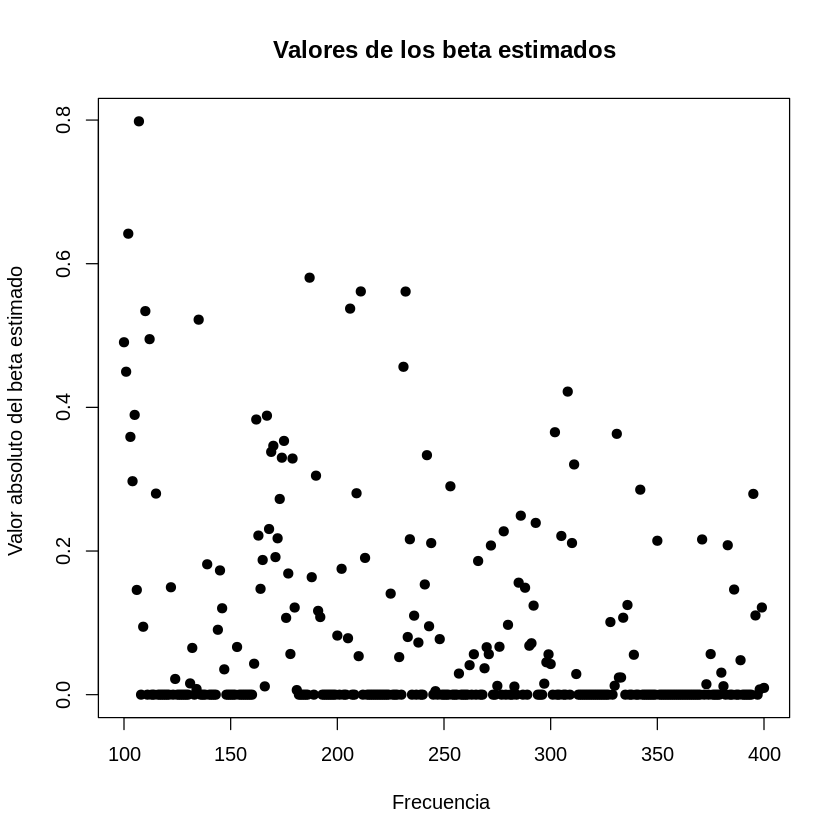

In [104]:
plot(x = seq(100, 400,1), y = abs(model$beta[,1]), main="Valores de los beta estimados",
     xlab="Frecuencia ", ylab="Valor absoluto del beta estimado ", pch=19)

### Analisis del grafico

En el presente grafico se puede observar la importancia que le da el modelo a las distintas variables $X_i$. Dado que el valor de $\alpha = 0.15 $ es cercano a cero, es esperable que muchas variables no sean tenidas en cuenta por el modelo (hay penalizacion por la distancia $L1$). Ademas, aunque no es muy notorio, pareciera que las variables a las que se les da mayor importancia son a las de frecuencia baja, mientras que a las de frecuencia alta, se les da poco protagonismo en el modelo

# Modelo 2: árbol de regresión

### Sin tuneo de parametros

In [126]:
model <- ctree(Y ~ ., data = TRAIN_DF)

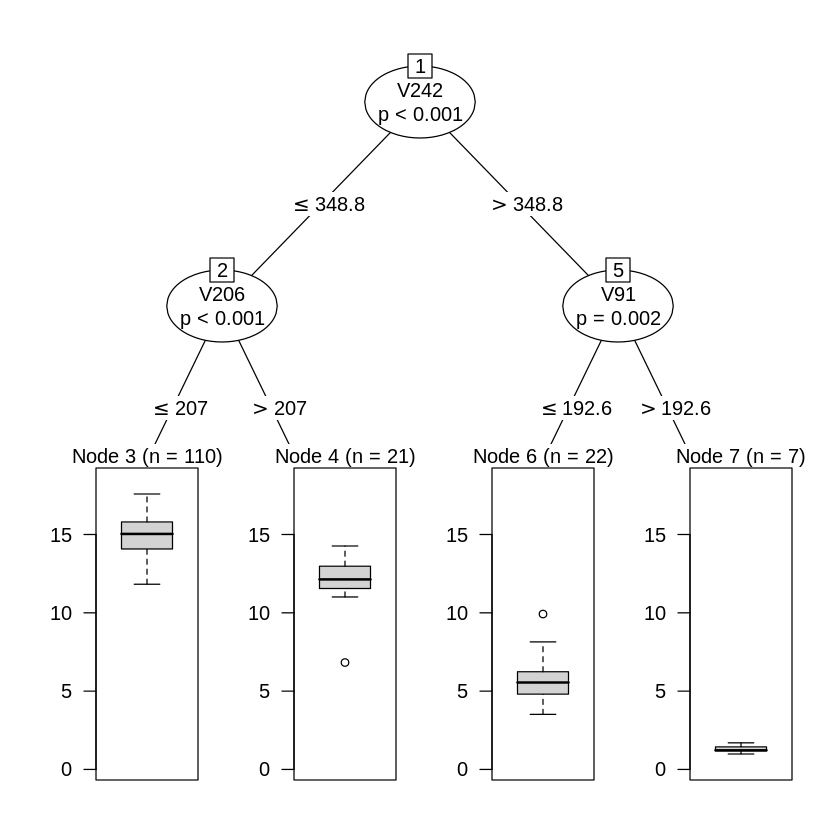

In [132]:
plot(model)

In [139]:
Y_pred = predict(model, TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  1.54697910764069"


### Busqueda de los parametros de la prediccion

In [116]:
setSeed()

n = nrow(TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  Alpha    =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)

for (minsplit in minsplits) {
    for (maxdepth in c(1, 2, 3, 4, 5, Inf)) {
        for (alpha in c(0.005, 0.01, 0.025, 0.05, 0.75, 0.1, 0.15)) {
            parametros = ctree_control(minsplit=minsplit, maxdepth=maxdepth, alpha=alpha)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]

                model <- ctree(Y ~ ., data = DF_train, control=parametros)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, alpha, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "Alpha", "Error")

El progreso es del 16.7 %
El progreso es del 33.3 %
El progreso es del 50 %
El progreso es del 66.7 %
El progreso es del 83.3 %
El progreso es del 100 %


In [117]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Minsplit,Maxdepth,Alpha,Error
40,2,Inf,0.75,2.001328


### Calculo del error

In [118]:
parametros <- ctree_control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, alpha=mejores_parametros$Alpha)

modelo2 <- ctree(Y ~ ., data = TRAIN_DF, control=parametros)

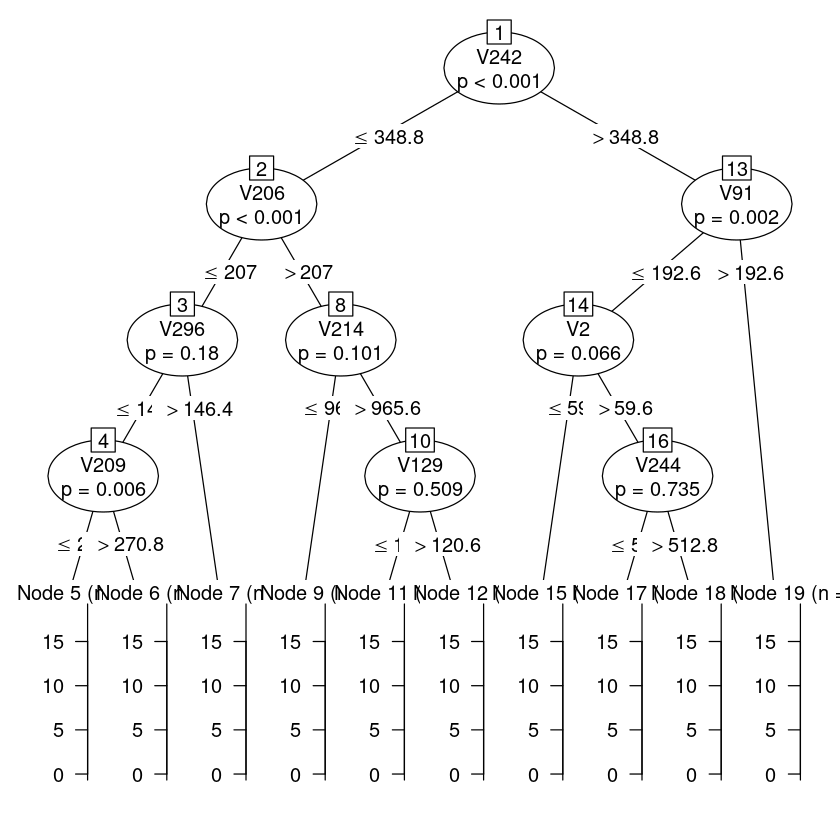

In [24]:
plot(modelo2)

In [151]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- ctree(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio de train es:  1.54697910764069"
[1] "El error cuadratico medio de test es:  0.983107098052772"
[1] "El error cuadratico medio con LOOCV de train es:  2.05346048565848"


# Modelo 3: KNN para regresión

In [25]:
library(reticulate)

In [26]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [27]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

### Sin tuneo de parametros

In [28]:
model <- knnr()$fit(TRAIN_X, TRAIN_Y)

In [32]:
Y_pred = as.double(model$predict(TRAIN_X))
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.81237114575"


### Busqueda de los parametros de la prediccion

In [33]:
setSeed()

n = nrow(TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- TRAIN_X

for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            err = 0
            for(i in indices){
                X_train_scaled = scale(X[-i,])
                Y_train = TRAIN_Y[-i]

                X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                              scale=attr(X_train_scaled, "scaled:scale"))
                Y_test = TRAIN_Y[i]

                model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)

                Y_pred = as.double(model$predict(X_test_scaled))
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(K, w, p, err/n))
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Error")

El progreso es del 10 %

El progreso es del 20 %

El progreso es del 30 %

El progreso es del 40 %

El progreso es del 50 %

El progreso es del 60 %

El progreso es del 70 %

El progreso es del 80 %

El progreso es del 90 %

El progreso es del 100 %



In [34]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,K,Weights,Distance,Error
,<int>,<dbl>,<dbl>,<dbl>
7,2,2,1,0.8483784


### Calculo del error

In [38]:
X_scaled <- scale(TRAIN_X)
X_holdout_scaled <- scale(HOLDOUT_X, center=attr(X_scaled, "scaled:center"),
                          scale=attr(X_scaled, "scaled:scale"))

wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
modelo3 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_scaled, TRAIN_Y)

Cálculo del error mediante LOOCV

In [43]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){
    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))
    Y_test = TRAIN_Y[i]
    
    wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.760177955352665"


# Modelo 4: regresión no paramétrica

$$\hat{m}_{h}(x) = \frac{\sum^{n}_{i=1} K(\frac{x-x_i}{h}) y_i}{\sum^{n}_{i=1}K(\frac{x-x_i}{h})} = \sum^{n}_{i=1} w_i(x) y_i$$

In [3]:
mNW <- function(x, X, Y, h, K = dnorm) {
    # Arguments
    # x: evaluation points
    # X: vector (size n) with the predictors
    # Y: vector (size n) with the response variable
    # h: bandwidth
    # K: kernel
    yi = c()
    for(xi in x){
        Ki = sapply(X, function(Xi) K((xi - Xi) / h))
        yi = c(yi, ifelse(sum(Ki)==0, mean(Y), sum(Ki*Y)/sum(Ki)))
    }
    return(yi)
}

In [4]:
corr_matrix <- cor(TRAIN_DF, method = "pearson")
corr_pesos <- corr_matrix[, 302][1:301]
corr_pesos <- abs(corr_pesos)

In [5]:
sum(corr_pesos) 

[1] 135.7105

In [6]:
setSeed()
n = nrow(TRAIN_X)
J = ncol(TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer()
)

hs = seq(0.01, 1, l=20)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(j in 1:J){
    busqueda <- data.frame(
        h       =double(),
        K       =integer(),
        Error   =double()
    )
    Xj = X[, j]
    for(h in hs){
        for(Knumber in 1:length(Ks)){
            K = Ks[[Knumber]]
            err = 0
            for(i in indices){
                Xj_train_scaled = scale(Xj[-i])
                Y_train = TRAIN_Y[-i]

                Xj_test_scaled = scale(Xj[i], center=attr(Xj_train_scaled, "scaled:center"),
                              scale=attr(Xj_train_scaled, "scaled:scale"))
                Y_test = TRAIN_Y[i]

                Y_pred = mNW(x = Xj_test_scaled, X = Xj_train_scaled, Y = Y_train, h = h, K=K)
                err = err + sum((Y_test - Y_pred)^2)
            }
            busqueda = rbind(busqueda, list(h, Knumber, err/n))
        }
    }
    colnames(busqueda)  <- c("h", "K", "Error")
    # Calculo de los mejores hp
    mejores_hp <- busqueda[which.min(busqueda$Error), ]
    resultados = rbind(resultados, list(mejores_hp$h, mejores_hp$K))
    message(progreso(j, 1:J))
}
colnames(resultados)  <- c("h", "K")

El progreso es del 0.3 %

El progreso es del 0.7 %

El progreso es del 1 %

El progreso es del 1.3 %

El progreso es del 1.7 %

El progreso es del 2 %

El progreso es del 2.3 %

El progreso es del 2.7 %

El progreso es del 3 %

El progreso es del 3.3 %

El progreso es del 3.7 %

El progreso es del 4 %

El progreso es del 4.3 %

El progreso es del 4.7 %

El progreso es del 5 %

El progreso es del 5.3 %

El progreso es del 5.6 %

El progreso es del 6 %

El progreso es del 6.3 %

El progreso es del 6.6 %

El progreso es del 7 %

El progreso es del 7.3 %

El progreso es del 7.6 %



In [63]:
vars16 <- c(1, 6, 8, 36, 59, 70, 74, 112, 126, 133, 142, 143, 193, 235, 242, 243)
pvars16 <- as.integer(seq(1, 301) %in% vars16)

In [95]:
pesos <- corr_pesos^20

Y_pred = 0
for(j in 1:J){
    Xj = scale(TRAIN_X[, j])
    mp_h = resultados$h[j]
    mp_K = resultados$K[j]
    Y_pred = Y_pred + pesos[j] * mNW(Xj, Xj, TRAIN_Y, mp_h, Ks[[mp_K]])
}t
Y_pred = Y_pred/sum(pesos)

In [96]:
mean((TRAIN_Y-Y_pred)^2)

[1] 2.220518

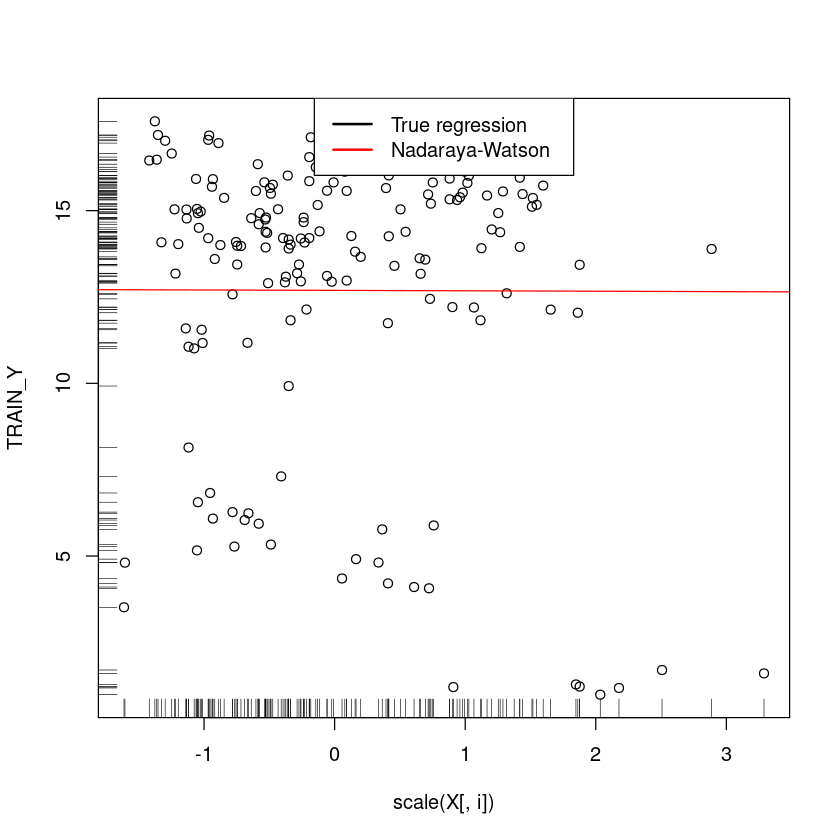

In [137]:
xGrid <- seq(-4, 4, l = 500)

plot(scale(X[,i]), TRAIN_Y)
i = 19
rug(scale(X[,i]), side = 1); rug(TRAIN_Y, side = 2)
lines(xGrid, mNW(x = xGrid, X = scale(X[,i]), Y = TRAIN_Y, h = 8), col = 2)
legend("top", legend = c("True regression", "Nadaraya-Watson"),
       lwd = 2, col = 1:2)